In [1]:
import torch
import transformers
import pandas as pd

print(torch.__version__)
print(transformers.__version__)

2.11.0+cpu
5.5.4


In [2]:
import sklearn
print("scikit-learn:", sklearn.__version__)

scikit-learn: 1.7.2


In [3]:
from datasets import load_dataset

dataset = load_dataset("go_emotions")
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 43410
    })
    validation: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5426
    })
    test: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5427
    })
})


In [4]:
dataset['train'][0]

{'text': "My favourite food is anything I didn't have to cook myself.",
 'labels': [27],
 'id': 'eebbqej'}

## Basics

In [5]:
from collections import Counter

label_counts = Counter()

for example in dataset['train']:
    for label in example['labels']:
        label_counts[label] += 1

print(label_counts)

Counter({27: 14219, 0: 4130, 4: 2939, 15: 2662, 3: 2470, 1: 2328, 7: 2191, 18: 2086, 10: 2022, 20: 1581, 2: 1567, 17: 1452, 6: 1368, 25: 1326, 9: 1269, 22: 1110, 5: 1087, 26: 1060, 13: 853, 11: 793, 8: 641, 14: 596, 24: 545, 12: 303, 19: 164, 23: 153, 21: 111, 16: 77})


In [6]:
label_names = dataset['train'].features['labels'].feature.names

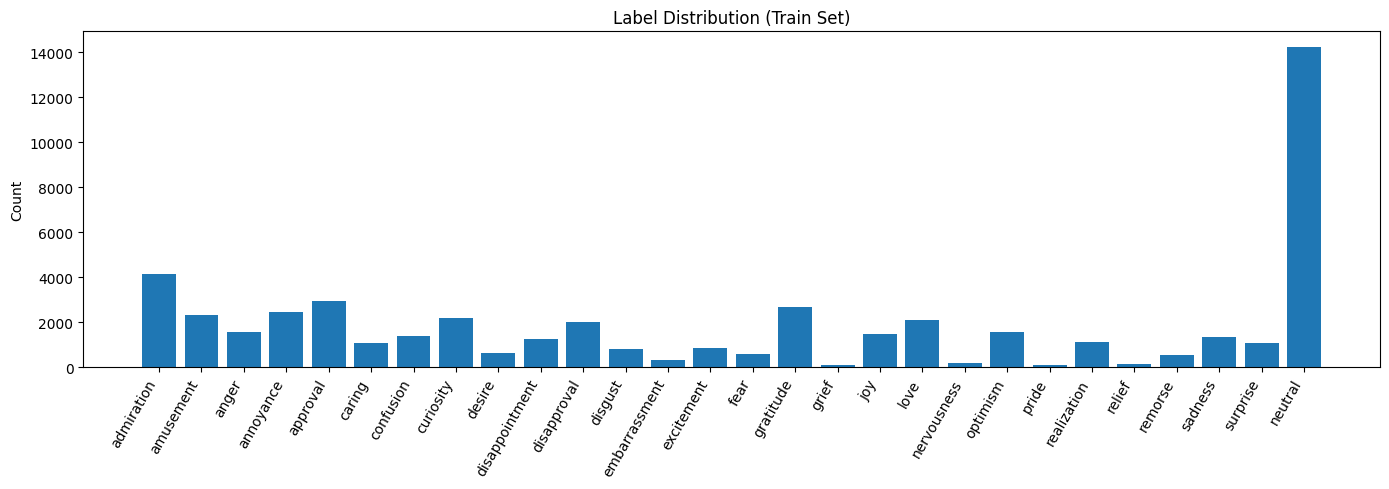

In [7]:
import matplotlib.pyplot as plt

labels_sorted = sorted(label_counts.items())
indices = [i for i, _ in labels_sorted]
counts = [c for _, c in labels_sorted]
names = [label_names[i] for i in indices]

plt.figure(figsize=(14, 5))
plt.bar(names, counts)
plt.xticks(rotation=60, ha='right')
plt.title("Label Distribution (Train Set)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

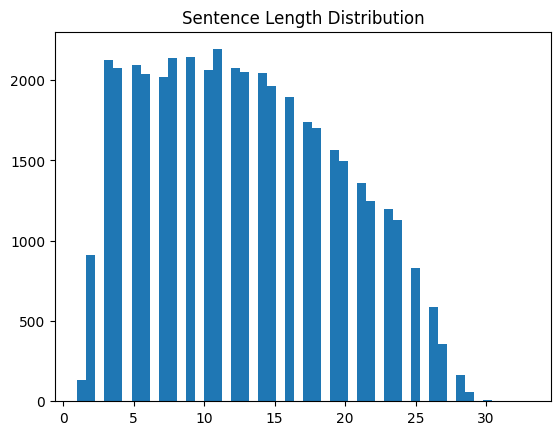

In [8]:
lengths = [len(x['text'].split()) for x in dataset['train']]

import matplotlib.pyplot as plt

plt.hist(lengths, bins=50)
plt.title("Sentence Length Distribution")
plt.show()

In [9]:
multi_label_counts = [len(x['labels']) for x in dataset['train']]

import numpy as np
print("Avg labels per sentence:", np.mean(multi_label_counts))

Avg labels per sentence: 1.1772172310527529


In [10]:
multi_label_samples = sum(1 for x in dataset['train'] if len(x['labels']) > 1)
print(f"Samples with >1 label: {multi_label_samples} ({100 * multi_label_samples / len(dataset['train']):.1f}%)")

Samples with >1 label: 7102 (16.4%)


In [11]:
from transformers import pipeline

classifier = pipeline(
    "text-classification",
    model="bhadresh-savani/bert-base-go-emotion",
    top_k=None
)

text = "I thought things would get better, but they didn't."
result = classifier(text)
print(result)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bhadresh-savani/bert-base-go-emotion
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[[{'label': 'neutral', 'score': 0.3548581004142761}, {'label': 'approval', 'score': 0.22213466465473175}, {'label': 'disapproval', 'score': 0.0798586905002594}, {'label': 'realization', 'score': 0.07927148044109344}, {'label': 'optimism', 'score': 0.06589163094758987}, {'label': 'confusion', 'score': 0.05748146027326584}, {'label': 'disappointment', 'score': 0.028134280815720558}, {'label': 'annoyance', 'score': 0.020755555480718613}, {'label': 'admiration', 'score': 0.01341696921736002}, {'label': 'curiosity', 'score': 0.011960366740822792}, {'label': 'desire', 'score': 0.01088994462043047}, {'label': 'caring', 'score': 0.007748621981590986}, {'label': 'surprise', 'score': 0.006373045966029167}, {'label': 'gratitude', 'score': 0.004172930493950844}, {'label': 'pride', 'score': 0.004102608654648066}, {'label': 'sadness', 'score': 0.00400075176730752}, {'label': 'anger', 'score': 0.003541393671184778}, {'label': 'relief', 'score': 0.003468309296295047}, {'label': 'disgust', 'score': 0.0

In [12]:
texts = [
    "I was excited to start this.",
    "But things quickly went wrong.",
    "Now I just feel numb."
]

for t in texts:
    print(t)
    print(classifier(t)[0])
    print()

I was excited to start this.
[{'label': 'excitement', 'score': 0.7617412805557251}, {'label': 'joy', 'score': 0.06238488107919693}, {'label': 'surprise', 'score': 0.032010942697525024}, {'label': 'neutral', 'score': 0.03173532336950302}, {'label': 'optimism', 'score': 0.015072544105350971}, {'label': 'admiration', 'score': 0.014533134177327156}, {'label': 'approval', 'score': 0.012270635925233364}, {'label': 'curiosity', 'score': 0.011867235414683819}, {'label': 'desire', 'score': 0.00932548101991415}, {'label': 'love', 'score': 0.009027608670294285}, {'label': 'realization', 'score': 0.007909230887889862}, {'label': 'gratitude', 'score': 0.005569408182054758}, {'label': 'caring', 'score': 0.004357147961854935}, {'label': 'amusement', 'score': 0.0030186062213033438}, {'label': 'annoyance', 'score': 0.00256307958625257}, {'label': 'sadness', 'score': 0.0022074361331760883}, {'label': 'pride', 'score': 0.002129731234163046}, {'label': 'disappointment', 'score': 0.0019208720186725259}, {'